### Import das Classes

In [20]:
import matplotlib.pyplot as plt

from src.ProblemaP1 import ProblemaP1
from src.ProblemGeneratorP1 import ProblemaP1Generator
from src.ProblemaP2 import ProblemaP2


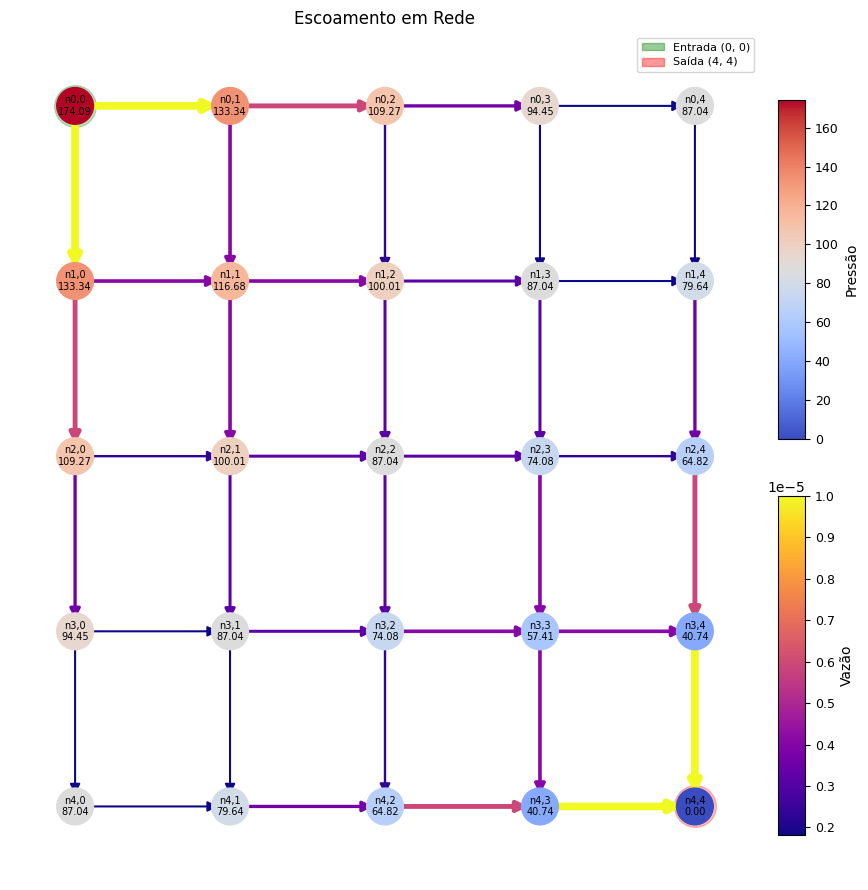

In [21]:
from src.Exemplos import set_grid_p1

p1 = set_grid_p1(5)
p1.solve()
p1.plot_grid()

In [ ]:
import numpy as np
import copy
from src.ProblemaP1 import ProblemaP1
from src.Grid import GridP1
from src.ProblemaP2 import ProblemaP2

def predial_params():
    mu = 1.0e-3
    D = 0.010
    area = np.pi * (D**2) / 4.0
    length = 1.0
    Q_in = 2.0e-5
    patm = 0.0
    return dict(mu=mu, area=area, length=length, Q_in=Q_in, patm=patm)

def instanciar_p1_base(n=10):
    """
    Cria uma malha quadrada (n x n) com fluxo linear distribuído.
    O fluido entra por toda a face esquerda e sai por toda a face direita.
    """
    params = predial_params()
    grid = GridP1(
        n=n, m=n, area=params['area'], length=params['length'],
        mu=params['mu'], patm=params['patm'], Q_in=params['Q_in']
    )
    
    # 1. Distribuindo a entrada em toda a borda esquerda (nós 0, n, 2n, ...)
    nos_esquerda = [i * n for i in range(n)]
    vazao_distribuida = params['Q_in'] / len(nos_esquerda)
    
    if hasattr(grid, 'set_inflow'):
        for no in nos_esquerda:
            grid.set_inflow(node=no, Q=vazao_distribuida)
            
    # 2. Fixando a pressão em toda a borda direita (nós n-1, 2n-1, 3n-1...)
    nos_direita = [i * n + (n - 1) for i in range(n)]
    
    if hasattr(grid, 'set_pressure'):
        for no in nos_direita:
            grid.set_pressure(node=no, p=params['patm'])
            
    return grid

def calcular_pf_para_margem(p1_base, p_max_nominal, margem, r_prob, alpha, n_prob, n_samp):
    """Função auxiliar que roda o ProblemaP2 para uma margem específica."""
    P_max_alvo = p_max_nominal * margem
    p2 = ProblemaP2(
        p1_instance=p1_base,
        r_prob=r_prob,
        alpha=alpha,
        P_max=P_max_alvo,
        n_problems=n_prob,
        n_samples=n_samp,
        seed=42 # CRÍTICO: Mesma seed para o Golden Search não se perder no ruído estocástico
    )
    p2.run()
    return p2.probability_of_failure()

def bisection_search():
    print("--- PREPARANDO MODELO BASE ---")
    p1_base = instanciar_p1_base(n=10) # Chama a nova malha
    p1_base.solve()
    p_max_nominal = np.max(p1_base.p)
    print(f"Pressão Máxima Nominal: {p_max_nominal:.4f} Pa\n")

    # PARÂMETROS SUAVES (Incrustação parcial)
    r_prob = 0.4    # 40% dos canos sofrem incrustação
    alpha = 3.0     # A condutância cai apenas 3x (não 1 milhão de vezes)
    n_prob = 30     # Aumente os problemas para a curva ficar bem definida
    n_samp = 200    
    
    # Limites iniciais (baseados no seu log: a transição está entre 0.98 e 1.05)
    a = 0.95  # Margem baixa -> P_f alto (esquema de falha garantida)
    b = 1.10  # Margem alta  -> P_f baixo (rede robusta)
    tol = 0.005 # Tolerância de 0.5% na margem

    print("--- INICIANDO BUSCA POR BISSEÇÃO ---")
    print("Objetivo: Encontrar a margem 'm' onde a transição de fase ocorre")
    
    iteracao = 1
    while (b - a) > tol:
        m_mid = (a + b) / 2.0
        pf_mid = calcular_pf_para_margem(p1_base, p_max_nominal, m_mid, r_prob, alpha, n_prob, n_samp)
        
        print(f"Iter {iteracao:02d} | Janela: [{a:.3f}, {b:.3f}] | Testando m_mid: {m_mid:.3f} -> P_f = {pf_mid:.4f}")
        
        # Como Pf cai conforme a margem (m) aumenta:
        # Se Pf está maior que 0.5, a margem está muito restrita (apertada). Subimos 'a'.
        if pf_mid > 0.5:
            a = m_mid
        # Se Pf está menor ou igual a 0.5, a margem está folgada demais. Descemos 'b'.
        else:
            b = m_mid
            
        iteracao += 1

    margem_otima = (a + b) / 2.0
    pf_final = calcular_pf_para_margem(p1_base, p_max_nominal, margem_otima, r_prob, alpha, n_prob, n_samp)
    
    print("\n--- RESULTADO DA BISSEÇÃO ---")
    print(f"Janela Crítica Final      : [{a:.4f}, {b:.4f}]")
    print(f"Margem Crítica Encontrada : {margem_otima:.4f} ({(margem_otima-1)*100:.1f}%)")
    print(f"Pressão Máxima de Falha   : {p_max_nominal * margem_otima:.4f} Pa")
    print(f"Probabilidade de Falha    : {pf_final:.4f}")

if __name__ == "__main__":
    bisection_search()
    
    print("\n--- RESULTADO DA BUSCA ---")
    print(f"Margem Crítica Encontrada : {margem_otima:.4f} ({(margem_otima-1)*100:.1f}%)")
    print(f"Pressão Máxima de Falha   : {p_max_nominal * margem_otima:.4f} Pa")
    print(f"Probabilidade de Falha    : {pf_final:.4f}")


--- PREPARANDO MODELO BASE ---
Pressão Máxima Nominal: 245.4129 Pa

--- INICIANDO BUSCA POR BISSEÇÃO ---
Objetivo: Encontrar a margem 'm' onde a transição de fase ocorre
Iter 01 | Janela: [0.950, 1.100] | Testando m_mid: 1.025 -> P_f = 0.0000
Iter 02 | Janela: [0.950, 1.025] | Testando m_mid: 0.987 -> P_f = 1.0000
Iter 03 | Janela: [0.987, 1.025] | Testando m_mid: 1.006 -> P_f = 0.0000
Iter 04 | Janela: [0.987, 1.006] | Testando m_mid: 0.997 -> P_f = 1.0000
Iter 05 | Janela: [0.997, 1.006] | Testando m_mid: 1.002 -> P_f = 0.0000


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Importe suas funções e classes (ajuste os caminhos conforme sua estrutura)
from src.Exemplos import predial_params
from src.Grid import GridP2

def executar_testes_estabilidade():
    # Carrega os parâmetros prediais padrão
    params = predial_params()
    n, m = 5, 5  # Grid 5x5
    
    # =====================================================================
    # PASSO 1: Determinar o cenário nominal e o limiar de falha (P_max)
    # =====================================================================
    print("--- PASSO 1: Definindo o P_max ---")
    # Instanciamos o grid e resolvemos como P1 para pegar as pressões normais
    grid_nominal = GridP2(n=n, m=m, **params)
    grid_nominal.solve() 
    
    pressao_maxima_nominal = np.max(grid_nominal.p)
    
    # Definindo P_max como 15% acima da pressão máxima normal
    P_max_falha = pressao_maxima_nominal * 1.15
    
    print(f"Pressão Máxima Nominal (sem obstrução): {pressao_maxima_nominal:.2f} Pa")
    print(f"Limiar de Falha (P_max) estipulado (+15%): {P_max_falha:.2f} Pa\n")


    # =====================================================================
    # PASSO 2: Teste de Convergência / Estabilidade Numérica (MC)
    # =====================================================================
    print("--- PASSO 2: Teste de Estabilidade (Aumentando n_samples) ---")
    amostras_lista = [10, 30, 50, 100, 200, 400]
    pf_estabilidade = []
    erros_inferior = []
    erros_superior = []
    
    for ns in amostras_lista:
        print(f"Simulando para n_samples = {ns}...")
        grid = GridP2(
            n=n, m=m, **params,
            r_prob=0.10,       # 10% de chance de obstrução
            alpha=3.0,         # Condutância cai para 1/3
            P_max=P_max_falha,
            n_problems=10,     # Mantemos 10 experimentos
            n_samples=ns,
            seed=42            # Semente fixa para reprodutibilidade
        )
        grid.run()
        res = grid.summary()
        
        pf_hat = res["P_f_hat"]
        ic_min, ic_max = res["IC_95%"]
        
        pf_estabilidade.append(pf_hat)
        # Para barras de erro simétricas no matplotlib:
        erros_inferior.append(pf_hat - ic_min)
        erros_superior.append(ic_max - pf_hat)


    # =====================================================================
    # PASSO 3: Teste de Sensibilidade (Mudando r_prob)
    # =====================================================================
    print("\n--- PASSO 3: Teste de Sensibilidade (Aumentando r_prob) ---")
    probabilidades_lista = [0.01, 0.05, 0.10, 0.15, 0.20, 0.30]
    pf_sensibilidade = []
    
    for r in probabilidades_lista:
        print(f"Simulando para r_prob = {r*100:.1f}%...")
        grid = GridP2(
            n=n, m=m, **params,
            r_prob=r,
            alpha=3.0,
            P_max=P_max_falha,
            n_problems=10,
            n_samples=100,  # Fixo em 100
            seed=42
        )
        grid.run()
        pf_sensibilidade.append(grid.summary()["P_f_hat"])


    # =====================================================================
    # PASSO 4: Visualização dos Resultados
    # =====================================================================
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Gráfico 1: Estabilidade de Monte Carlo
    ax1.errorbar(amostras_lista, pf_estabilidade, 
                 yerr=[erros_inferior, erros_superior], 
                 fmt='-o', color='b', capsize=5, ecolor='red')
    ax1.set_title("Convergência do Estimador (Estabilidade)")
    ax1.set_xlabel("Número de Simulações (n_samples)")
    ax1.set_ylabel("Probabilidade de Falha Estimada ($P_f$)")
    ax1.grid(True, linestyle='--', alpha=0.7)
    
    # Gráfico 2: Sensibilidade ao risco de entupimento
    ax2.plot(probabilidades_lista, pf_sensibilidade, '-o', color='purple')
    ax2.set_title("Impacto da Probabilidade de Obstrução")
    ax2.set_xlabel("Probabilidade de Obstrução na Aresta ($r\_prob$)")
    ax2.set_ylabel("Probabilidade de Falha da Rede ($P_f$)")
    ax2.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    executar_testes_estabilidade()

--- PASSO 1: Definindo o P_max ---
Pressão Máxima Nominal (sem obstrução): 174.09 Pa
Limiar de Falha (P_max) estipulado (+15%): 200.20 Pa

--- PASSO 2: Teste de Estabilidade (Aumentando n_samples) ---
Simulando para n_samples = 10...


AttributeError: 'NoneType' object has no attribute 'tolil'